<h1 style="
background:#0B3D91;
color:white;
padding:18px;
border-radius:10px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
Credit Card Customer Segmentation
</h1>

<p style="text-align:center;font-size:17px;font-family:Arial, Helvetica, sans-serif;">
<strong>Unsupervised Learning Portfolio Project</strong><br>
K-Means, PCA, Gaussian Mixture Models and Exploratory Factor Analysis
</p>

---

## Table of Contents

1. [Project Overview](#project-overview)  
2. [Research Questions and Analytical Contribution](#research-questions)  
3. [Reproducibility and Dataset Loading](#dataset-loading)  
4. [Preprocessing and Exploratory Data Analysis](#data)  
5. [Baseline Customer Segmentation with K-Means](#baseline-kmeans)  
6. [Dimensionality Reduction with PCA](#pca)  
7. [Gaussian Mixture Models](#gmmpca)  
8. [Exploratory Factor Analysis](#efa)  
9. [Model Comparison and Business Interpretation](#model-comparison)  
10. [Final Conclusions](#final-conclusions)

> **Note on originality.** This notebook uses a public customer dataset, but the analytical narrative, extended model comparison, tables, visual interpretation and final segmentation discussion are organized as an independent data science project.


<a id="project-overview"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
1. Project Overview
</h1>

This project analyzes the behavior of credit card customers using unsupervised learning. The goal is not only to assign customers to clusters, but also to explain the economic and behavioral meaning of each segment.

The analysis is built around four ideas:

- **Customer behavior:** how users differ in balance, purchases, payments, cash advances, credit limit and tenure.
- **Segmentation quality:** whether the groups are internally coherent and externally different.
- **Dimensionality reduction:** how PCA helps visualize high-dimensional behavior without replacing the full modeling logic.
- **Business interpretation:** how each segment can support marketing, credit risk monitoring and customer relationship strategies.

Unlike a simple clustering exercise, this notebook combines preprocessing, exploratory analysis, K-Means, PCA, Gaussian Mixture Models and Exploratory Factor Analysis. Each relevant table and chart is interpreted so the technical results can be translated into a business-oriented explanation.


<a id="research-questions"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
2. Research Questions and Analytical Contribution
</h1>

### Main research question

How can credit card customers be segmented into meaningful behavioral groups using unsupervised learning methods?

### Specific questions

1. Which variables show the strongest differences between customers?
2. How many clusters provide a reasonable balance between statistical performance and interpretability?
3. Do PCA and factor analysis reveal simpler latent dimensions behind customer behavior?
4. Are the segments stable when comparing K-Means with probabilistic clustering through Gaussian Mixture Models?
5. What practical interpretation can be assigned to each customer group?

### Contribution of this notebook

This version goes beyond a basic K-Means workflow by adding:

- a clearer business problem formulation;
- explicit interpretation after tables and plots;
- comparison between clustering methods;
- PCA as a visualization and dimensionality-reduction tool;
- factor analysis as an additional latent-structure approach;
- a final segmentation narrative suitable for a public GitHub portfolio.


<a id="dataset-loading"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
3. Reproducibility and Dataset Loading
</h1>

The dataset contains behavioral information from credit card customers. Since the data is public, the originality of this project comes from the analytical decisions, the modeling sequence, the interpretation of the results and the way the methodology is documented.

For GitHub reproducibility, the dataset is loaded from the local project structure:

```text
data/Customer_Data.csv
```

If the notebook is executed in another environment, the loading cell also checks common alternative locations.


<a id="importing"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
4. Library Import
</h1>

The following libraries are used for data manipulation, visualization, preprocessing, clustering, dimensionality reduction and model evaluation.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, FactorAnalysis

<a id="loading"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
5. Dataset Loading
</h1>

This step reads the customer dataset and creates the working dataframe. The path is written in a portable way so the notebook can be executed from a GitHub repository without depending on a personal Windows directory.


In [2]:
possible_paths = [
    Path("data/Customer_Data.csv"),
    Path("../data/Customer_Data.csv"),
    Path("Customer_Data.csv"),
    Path("/mnt/data/Customer_Data.csv")
]

data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Customer_Data.csv was not found. Place the file inside the 'data/' folder "
        "or update the path in this cell."
    )

data = pd.read_csv(data_path)
df = data.copy()

print(f"Dataset loaded from: {data_path}")
df.head()

Dataset loaded from: Customer_Data.csv


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONE_OFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONE_OFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


<span style="color:#1F4E79;font-weight:700;font-size:20px">
&#10148; Conversion of column names to title format
</span>


In [3]:
df.columns = [i.title() for i in df.columns]
df.columns

Index(['Cust_Id', 'Balance', 'Balance_Frequency', 'Purchases',
       'One_Off_Purchases', 'Installments_Purchases', 'Cash_Advance',
       'Purchases_Frequency', 'One_Off_Purchases_Frequency',
       'Purchases_Installments_Frequency', 'Cash_Advance_Frequency',
       'Cash_Advance_Trx', 'Purchases_Trx', 'Credit_Limit', 'Payments',
       'Minimum_Payments', 'Prc_Full_Payment', 'Tenure'],
      dtype='str')

<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; Description of the dataset columns
</span>

The dataset summarizes the behavior of 8,950 credit card holders over the last 6 months and consists of 18 variables.

Id | Variable | Description
--|:---------|:-----------
1|**Cust_Id:**| Identification of the card holder
2|**Balance:**| Remaining account balance available for purchases
3|**Balance_Frequency:**| Frequency with which the balance is updated (1=frequent, 0=not frequent)
4|**Purchases:**| Total amount of purchases made
5|**One_Off_Purchases:**| Maximum one-time purchase amount
6|**Installments_Purchases:**| Amount of installment purchases
7|**Cash_Advance:**| Cash advance taken by the user
8|**Purchases_Frequency:**| Purchase frequency (1=frequent, 0=not frequent)
9|**One_Off_Purchases_Frequency:**| Frequency of one-time purchases
10|**Purchases_Installments_Frequency:**| Frequency of installment purchases
11|**Cash_Advance_Frequency:**| Cash advance frequency
12|**Cash_Advance_Trx:**| Number of cash advance transactions
13|**Purchases_Trx:**| Number of purchase transactions
14|**Credit_Limit:**| User credit limit
15|**Payments:**| Total amount of payments made
16|**Minimum_Payments:**| Minimum payment amount made
17|**Prc_Full_Payment:**| Percentage of full payment made
18|**Tenure:**| Length of credit card service


<a id="data"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
6. Preprocessing and Exploratory Data Analysis
</h1>

<span style="color:#1F4E79;font-weight:700;font-size:20px">
&#10148; Dataset shape and information
</span>

In [4]:
print("Number of rows", (df.shape[0]))
print("Number of columns", (df.shape[1]))

Number of rows 8950
Number of columns 18


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Cust_Id                           8950 non-null   str    
 1   Balance                           8950 non-null   float64
 2   Balance_Frequency                 8950 non-null   float64
 3   Purchases                         8950 non-null   float64
 4   One_Off_Purchases                 8950 non-null   float64
 5   Installments_Purchases            8950 non-null   float64
 6   Cash_Advance                      8950 non-null   float64
 7   Purchases_Frequency               8950 non-null   float64
 8   One_Off_Purchases_Frequency       8950 non-null   float64
 9   Purchases_Installments_Frequency  8950 non-null   float64
 10  Cash_Advance_Frequency            8950 non-null   float64
 11  Cash_Advance_Trx                  8950 non-null   int64  
 12  Purchases_Trx    

✅ **Observations:**
* The dataset contains 18 columns and 8,950 rows.
* "Cust_Id" is an object type variable.
* "Cash_Advance_Trx", "Purchases_Trx" and "Tenure" are int64. The remaining variables are float64.


<span style="color:#1F4E79;font-weight:700;font-size:20px">
&#10148; Statistical summary of the dataset
</span>


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Cust_Id,8950,8950,C10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balance,8950.0,NaN,NaN,NaN,1564.474828,2081.531879,0.0,128.281915,873.385231,2054.140036,19043.13856
Balance_Frequency,8950.0,NaN,NaN,NaN,0.877271,0.236904,0.0,0.888889,1.0,1.0,1.0
Purchases,8950.0,NaN,NaN,NaN,1003.204834,2136.634782,0.0,39.635,361.28,1110.13,49039.57
One_Off_Purchases,8950.0,NaN,NaN,NaN,592.437371,1659.887917,0.0,0.0,38.0,577.405,40761.25
Installments_Purchases,8950.0,NaN,NaN,NaN,411.067645,904.338115,0.0,0.0,89.0,468.6375,22500.0
Cash_Advance,8950.0,NaN,NaN,NaN,978.871112,2097.163877,0.0,0.0,0.0,1113.821139,47137.21176
Purchases_Frequency,8950.0,NaN,NaN,NaN,0.490351,0.401371,0.0,0.083333,0.5,0.916667,1.0
One_Off_Purchases_Frequency,8950.0,NaN,NaN,NaN,0.202458,0.298336,0.0,0.0,0.083333,0.3,1.0
Purchases_Installments_Frequency,8950.0,NaN,NaN,NaN,0.364437,0.397448,0.0,0.0,0.166667,0.75,1.0


<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; Duplicate values:
</span>


In [7]:
print("Duplicate values in df:", df.duplicated().sum())

Duplicate values in df: 0


<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; Missing values:
</span>


In [8]:
df.isnull().sum()

Cust_Id                               0
Balance                               0
Balance_Frequency                     0
Purchases                             0
One_Off_Purchases                     0
Installments_Purchases                0
Cash_Advance                          0
Purchases_Frequency                   0
One_Off_Purchases_Frequency           0
Purchases_Installments_Frequency      0
Cash_Advance_Frequency                0
Cash_Advance_Trx                      0
Purchases_Trx                         0
Credit_Limit                          1
Payments                              0
Minimum_Payments                    313
Prc_Full_Payment                      0
Tenure                                0
dtype: int64

✅ **Observations:**
* There are 313 missing values in "Minimum_Payments" and 1 missing value in "Credit_Limit".


<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; Data cleaning
</span>


In [9]:
df1 = df.copy()
df1.head()

,Cust_Id,Balance,Balance_Frequency,Purchases,One_Off_Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Purchases_Installments_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [10]:
df_2 = df1[df1["Minimum_Payments"].isna() == True]
df_3 = df_2[df_2["Payments"] == 0]
print("Rows where Minimum_Payments is NaN and Payments is 0:", len(df_3))
df_3.head()

Rows where Minimum_Payments is NaN and Payments is 0: 240


,Cust_Id,Balance,Balance_Frequency,Purchases,One_Off_Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Purchases_Installments_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.0,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.0,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.0,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.0,NaN,0.0,12
56,C10058,3625.218146,1.000000,313.27,313.27,0.0,668.468743,0.250000,0.250000,0.000000,0.416667,5,4,4000.0,0.0,NaN,0.0,12


In 240 rows of df1, "Minimum_Payments" is NaN and "Payments" is 0 at the same time. If there are no payments in the bank account, the minimum payment is also zero. Therefore, these missing values are replaced with 0.


In [11]:
zero_mask = (df1["Payments"] == 0) & (df1["Minimum_Payments"].isna())
df1.loc[zero_mask, "Minimum_Payments"] = 0

df1.isnull().sum()

Cust_Id                              0
Balance                              0
Balance_Frequency                    0
Purchases                            0
One_Off_Purchases                    0
Installments_Purchases               0
Cash_Advance                         0
Purchases_Frequency                  0
One_Off_Purchases_Frequency          0
Purchases_Installments_Frequency     0
Cash_Advance_Frequency               0
Cash_Advance_Trx                     0
Purchases_Trx                        0
Credit_Limit                         1
Payments                             0
Minimum_Payments                    73
Prc_Full_Payment                     0
Tenure                               0
dtype: int64

Now only 73 missing values remain in "Minimum_Payments".


In [12]:
missing_pct_cl = 100 * df1["Credit_Limit"].isnull().sum() / len(df1)
missing_pct_mp = 100 * df1["Minimum_Payments"].isnull().sum() / len(df1)
print("Percentage of missing values in 'Credit_Limit':", round(missing_pct_cl, 2), "%")
print("Percentage of missing values in 'Minimum_Payments':", round(missing_pct_mp, 2), "%")

Percentage of missing values in 'Credit_Limit': 0.01 %
Percentage of missing values in 'Minimum_Payments': 0.82 %


The percentage of missing values is small (0.82% and 0.01%, respectively). The remaining rows with missing values are removed.


In [13]:
df1.dropna(inplace=True)

In [14]:
df1.isnull().sum()

Cust_Id                             0
Balance                             0
Balance_Frequency                   0
Purchases                           0
One_Off_Purchases                   0
Installments_Purchases              0
Cash_Advance                        0
Purchases_Frequency                 0
One_Off_Purchases_Frequency         0
Purchases_Installments_Frequency    0
Cash_Advance_Frequency              0
Cash_Advance_Trx                    0
Purchases_Trx                       0
Credit_Limit                        0
Payments                            0
Minimum_Payments                    0
Prc_Full_Payment                    0
Tenure                              0
dtype: int64

The 'Cust_Id' column does not provide information for the model, so it is removed.


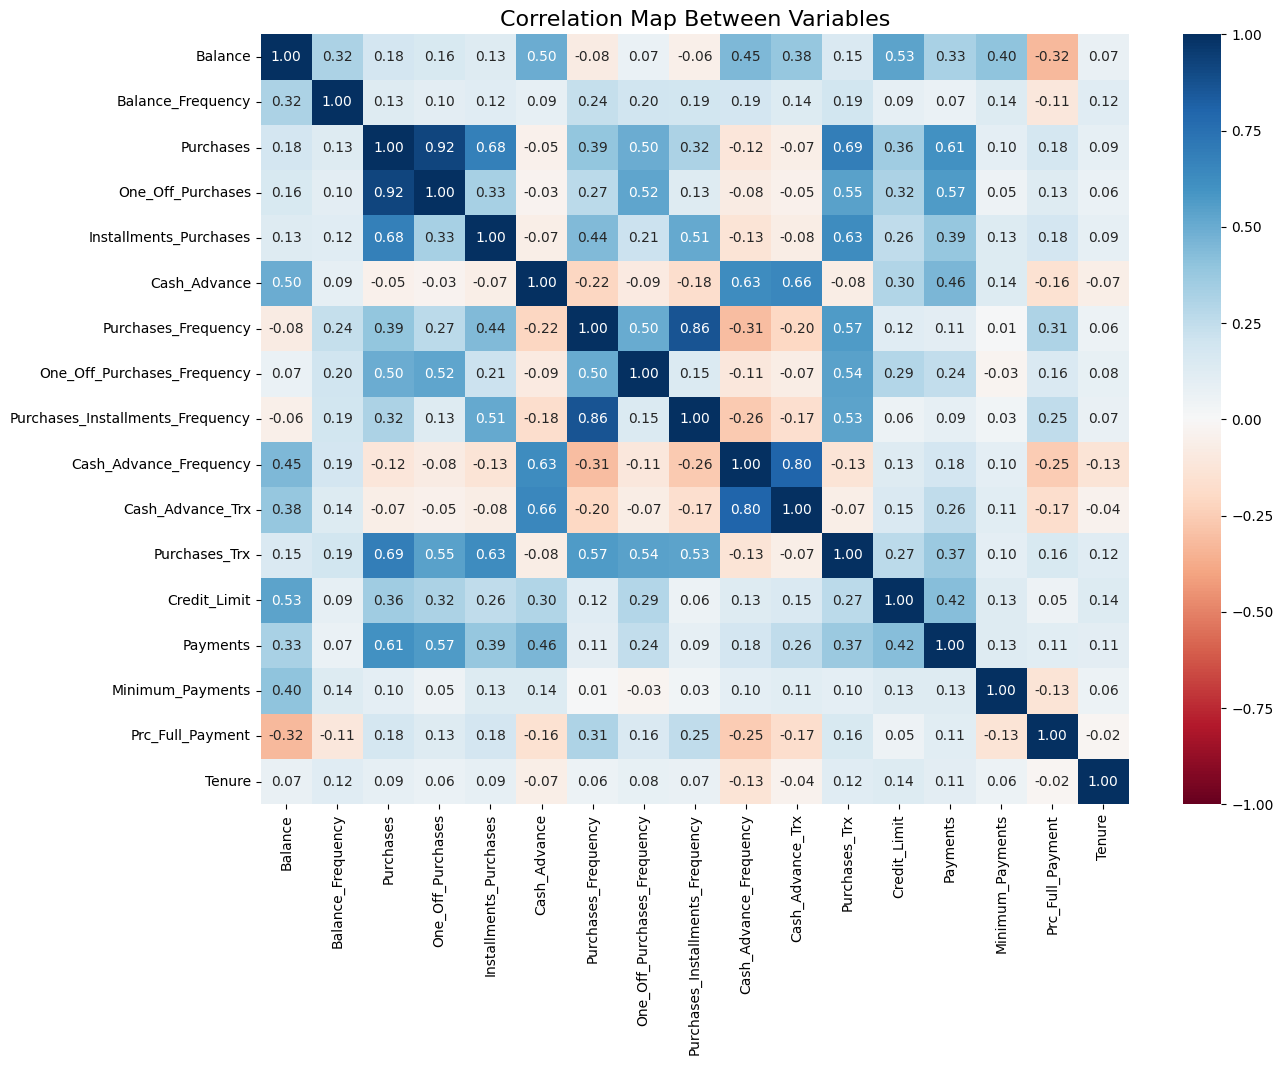

In [15]:
corr_matrix = df1.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Map Between Variables", fontsize=16)
plt.show()

In [16]:
df1= df1.drop(columns=['One_Off_Purchases', 'Purchases_Installments_Frequency'])


In [17]:
FULL_DF = df1.groupby("Cust_Id").agg({"Balance": "mean", "Balance_Frequency": "mean", "Purchases": "mean", "Installments_Purchases": "mean", "Cash_Advance": "mean", "Purchases_Frequency": "mean", "One_Off_Purchases_Frequency": "mean", "Cash_Advance_Frequency": "mean", "Cash_Advance_Trx": "mean", "Purchases_Trx": "mean", "Credit_Limit": "mean", "Payments": "mean", "Minimum_Payments": "mean", "Prc_Full_Payment": "mean", "Tenure": "mean"})
FULL_DF.head()

,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure
Cust_Id,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,95.4,0.000000,0.166667,0.000000,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
C10002,3202.467416,0.909091,0.00,0.0,6442.945483,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
C10003,2495.148862,1.000000,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
C10004,1666.670542,0.636364,1499.00,0.0,205.788017,0.083333,0.083333,0.083333,1.0,1.0,7500.0,0.000000,0.000000,0.000000,12.0
C10005,817.714335,1.000000,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


<span style="color:#1F4E79;font-weight:700;font-size:20px">
&#10148; Unique categories of categorical variables
</span>


In [20]:
print(df1["Tenure"].unique())

[12  8 11  9 10  6  7]


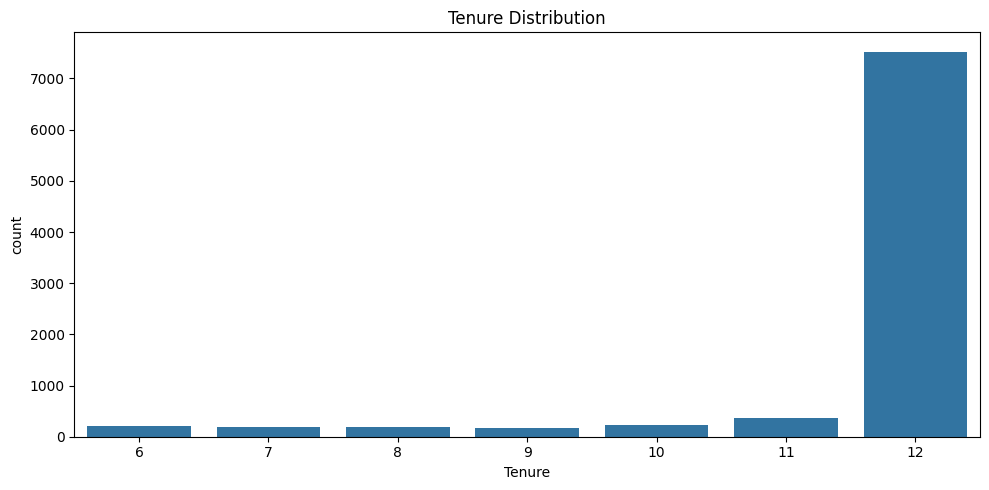

In [21]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df1["Tenure"])
plt.title("Tenure Distribution")
plt.tight_layout()
plt.show()

<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; Distribution visualization
</span>


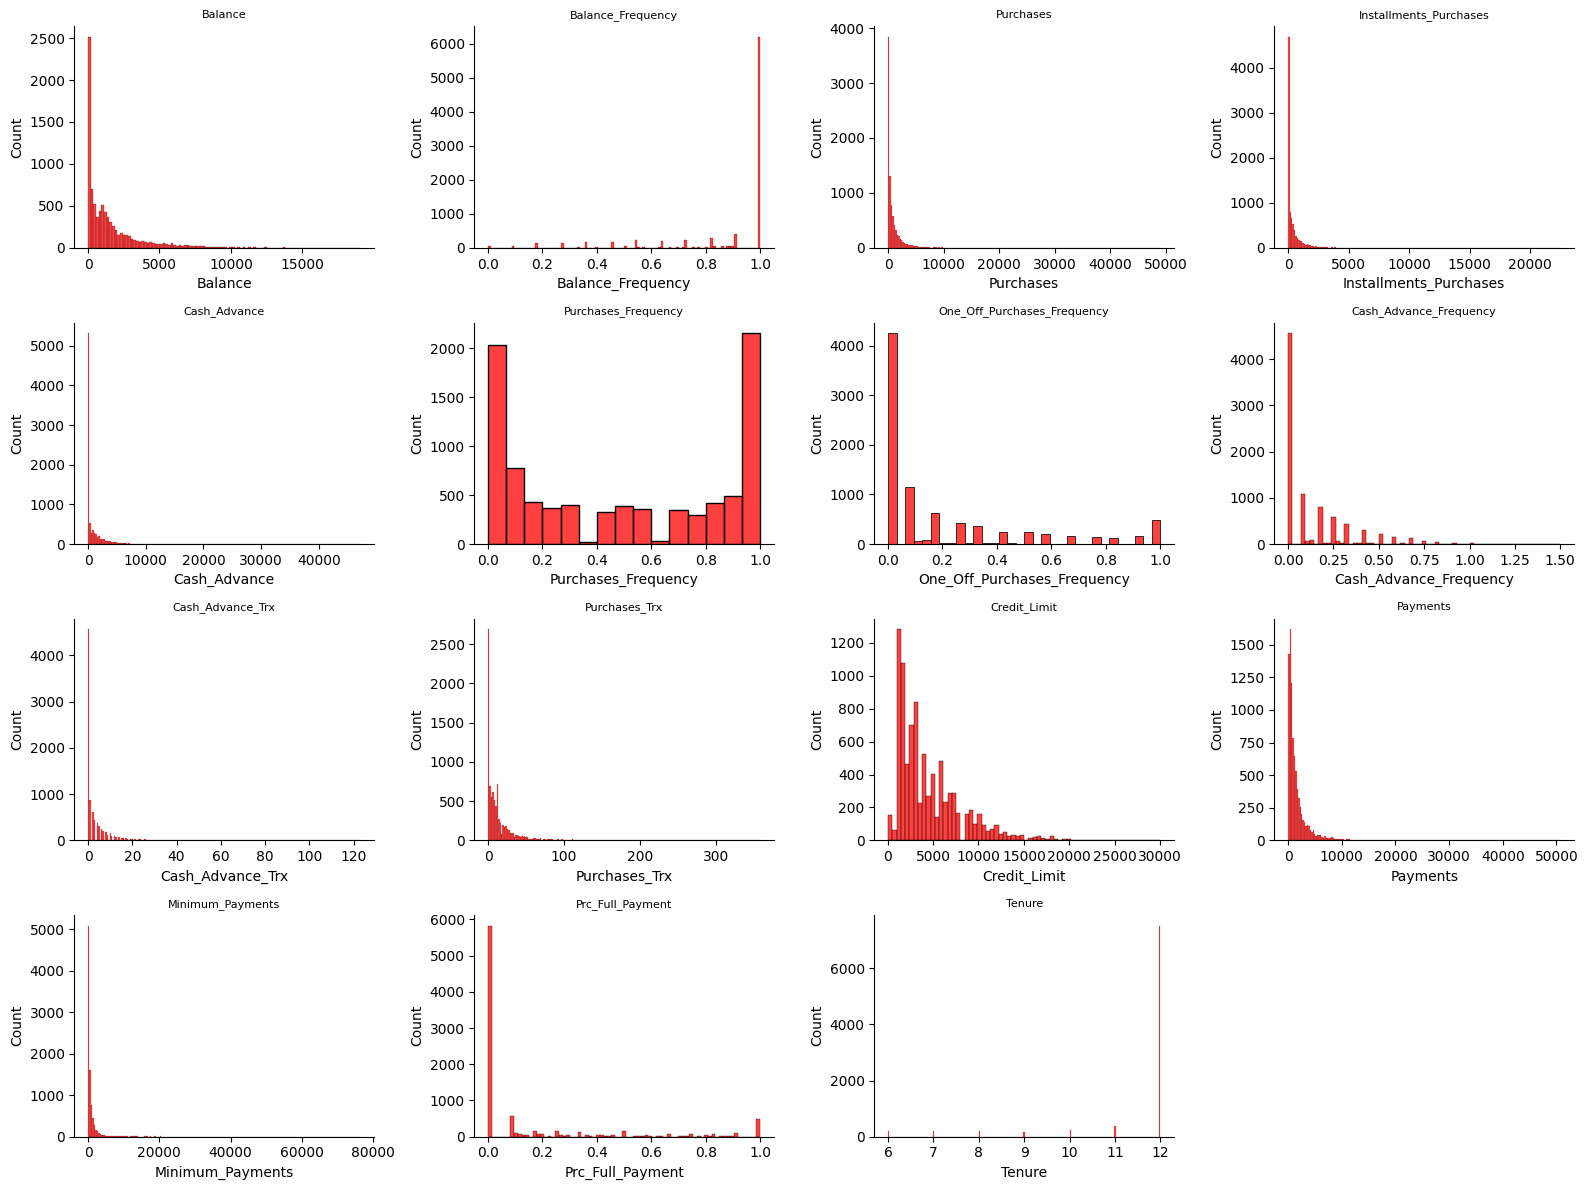

In [22]:
cols = FULL_DF.columns.tolist()
n_cols = len(cols)

n_rows = (n_cols + 3) // 4
fig, axs = plt.subplots(nrows=n_rows, ncols=4, figsize=(16, n_rows * 3))
axs = axs.flatten()

for idx, col in enumerate(cols):
    sns.histplot(df1[col], color="red", ax=axs[idx], kde=False)
    axs[idx].set_title(col, fontsize=8)
    sns.despine()

for idx in range(len(cols), len(axs)):
    axs[idx].set_visible(False)

plt.tight_layout()
plt.show()

<a id="baseline-kmeans"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
7. Baseline Customer Segmentation with K-Means
</h1>

This section builds the first segmentation model using the complete scaled dataset. The original variables are then used only for interpretation, so the business meaning of each cluster remains clear.

<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; Normalization (Standardization):
</span>

Before applying KMeans, the data are standardized with StandardScaler so that all variables have mean=0 and standard deviation=1.

In [23]:
VARIABLES = ['Balance', 'Purchases', 'Credit_Limit', 'Payments']

X = FULL_DF[VARIABLES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

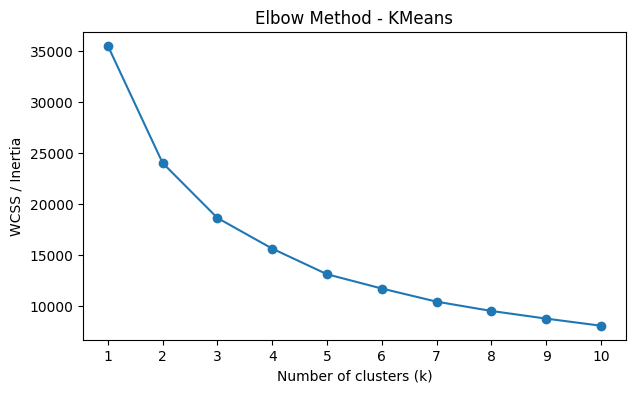

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method - KMeans")
plt.xticks(k_range)
plt.show()

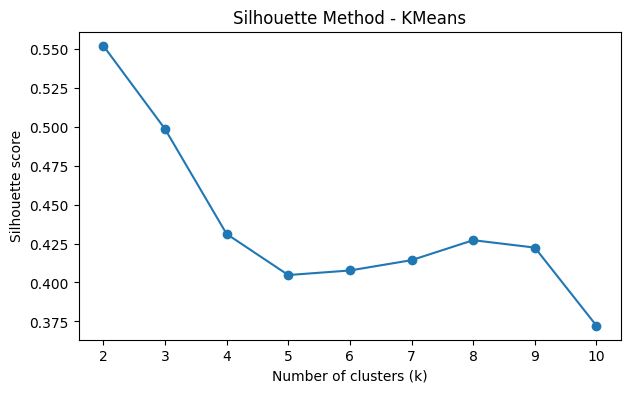

In [25]:
silhouette = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), silhouette, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Method - KMeans')
plt.xticks(range(2, 11))
plt.show()



In [26]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
FULL_DF['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

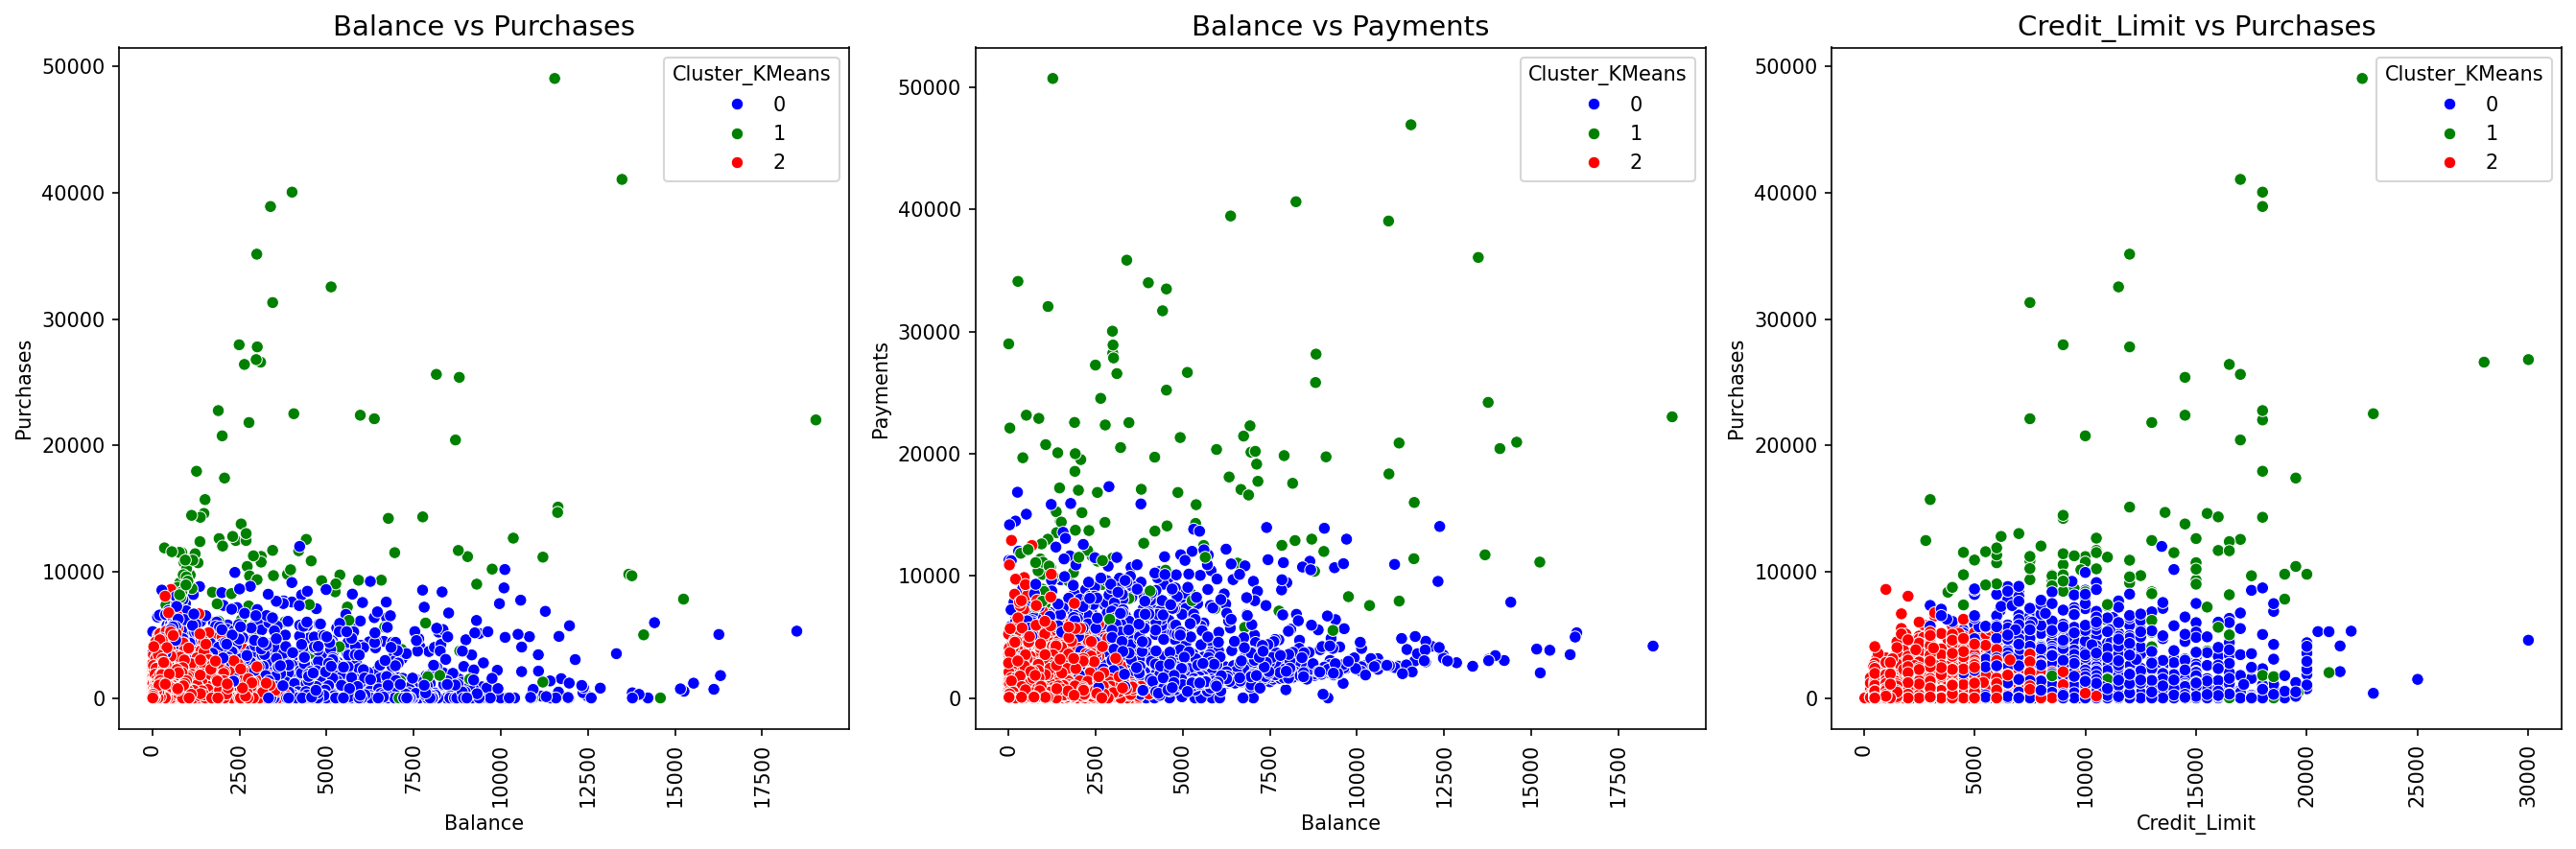

In [32]:
fig = plt.figure(figsize=(18, 6), dpi=150) 

plt.subplot(1, 3, 1)
sns.scatterplot(data=FULL_DF, x="Balance", y="Purchases", hue="Cluster_KMeans", palette=["#1F77B4", "#FF7F0E", "#D62728"])
plt.title("Balance vs Purchases", fontsize=14) # Un tamaño menor para que quepa bien
plt.xticks(rotation=90, fontsize=10)

plt.subplot(1, 3, 2)
sns.scatterplot(data=FULL_DF, x="Balance", y="Payments", hue="Cluster_KMeans", palette=["#1F77B4", "#FF7F0E", "#D62728"])
plt.title("Balance vs Payments", fontsize=14)
plt.xticks(rotation=90, fontsize=10)

plt.subplot(1, 3, 3)
sns.scatterplot(data=FULL_DF, x="Credit_Limit", y="Purchases", hue="Cluster_KMeans", palette=["#1F77B4", "#FF7F0E", "#D62728"])
plt.title("Credit_Limit vs Purchases", fontsize=14)
plt.xticks(rotation=90, fontsize=10)

plt.tight_layout()
plt.show()

In Balance vs Purchases, customers with very high purchases mainly belong to cluster 1, while cluster 2 remains in the lower consumption area. In Balance vs Payments, cluster 1 also shows high payments, suggesting customers with greater financial movement capacity. Cluster 0 has high balances but more contained payments and purchases, which may indicate credit use more oriented toward debt or cash advances than purchases. Finally, cluster 2 in both graphs represents customers with low balances, payments and purchases, reflecting customers with low balances and low payment and consumption capacity.


In Credit_Limit vs Purchases, the orange points (cluster 1) confirm that a higher credit limit is associated with a higher purchase volume, while the red cluster (cluster 2) remains at low limits and low purchases.


<a id="kmeans"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
8. K-Means Modeling and Cluster Validation
</h1>

The number of clusters is evaluated with inertia and silhouette analysis. The final selection balances statistical criteria with interpretability.



In [33]:
FULL_DF = df1.groupby("Cust_Id").agg({"Balance": "mean", "Balance_Frequency": "mean", "Purchases": "mean", "Installments_Purchases": "mean", "Cash_Advance": "mean", "Purchases_Frequency": "mean", "One_Off_Purchases_Frequency": "mean", "Cash_Advance_Frequency": "mean", "Cash_Advance_Trx": "mean", "Purchases_Trx": "mean", "Credit_Limit": "mean", "Payments": "mean", "Minimum_Payments": "mean", "Prc_Full_Payment": "mean", "Tenure": "mean"})
FULL_DF.head()

,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure
Cust_Id,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,95.4,0.000000,0.166667,0.000000,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
C10002,3202.467416,0.909091,0.00,0.0,6442.945483,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
C10003,2495.148862,1.000000,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
C10004,1666.670542,0.636364,1499.00,0.0,205.788017,0.083333,0.083333,0.083333,1.0,1.0,7500.0,0.000000,0.000000,0.000000,12.0
C10005,817.714335,1.000000,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


In [34]:
model_variables = FULL_DF.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(FULL_DF)

X_scaled = pd.DataFrame(X_scaled, columns=model_variables, index=FULL_DF.index)

X_scaled.head()

,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure
Cust_Id,,,,,,,,,,,,,,,
C10001,-0.736905,-0.287766,-0.426040,-0.349910,-0.468992,-0.806206,-0.681576,-0.678664,-0.478306,-0.512413,-0.961640,-0.531938,-0.299201,-0.528346,0.359995
C10002,0.779306,0.113037,-0.470533,-0.455019,2.593303,-1.221417,-0.681576,0.567547,0.105923,-0.592596,0.684124,0.820499,0.098709,0.229157,0.359995
C10003,0.440093,0.513839,-0.109937,-0.455019,-0.468992,1.269844,2.662996,-0.678664,-0.478306,-0.111498,0.821271,-0.386245,-0.091135,-0.528346,0.359995
C10004,0.042775,-1.089371,0.228579,-0.455019,-0.371182,-1.013812,-0.402863,-0.263262,-0.332249,-0.552505,0.821271,-0.601897,-0.358710,-0.528346,0.359995
C10005,-0.364364,0.513839,-0.463071,-0.455019,-0.468992,-1.013812,-0.402863,-0.678664,-0.478306,-0.552505,-0.906781,-0.366739,-0.254292,-0.528346,0.359995


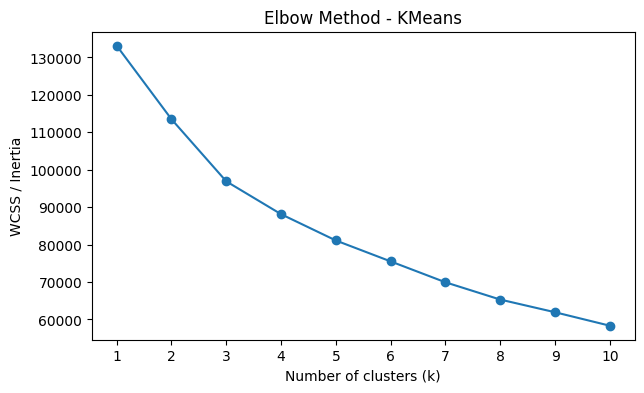

In [35]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method - KMeans")
plt.xticks(k_range)
plt.show()

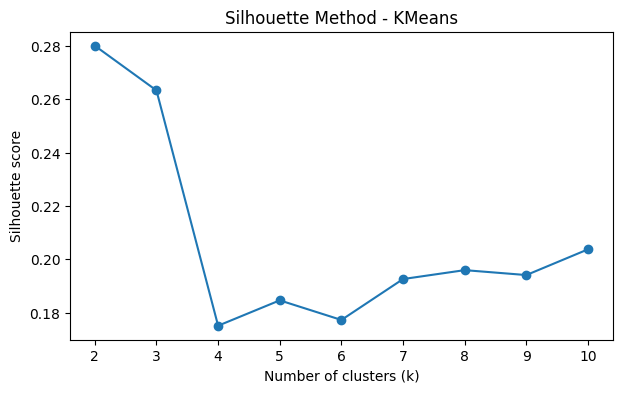

Best k according to silhouette: 2


In [36]:
silhouette = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), silhouette, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Method - KMeans')
plt.xticks(range(2, 11))
plt.show()

best_k = range(2, 11)[silhouette.index(max(silhouette))]
print('Best k according to silhouette:', best_k)

<span style="color:#1F4E79;font-weight:700;font-size:22px"> &#10148; Final KMeans model </span>

To keep the segmentation clear and comparable with the previous analysis, the model uses **3 clusters**.


Customer distribution by cluster:


,n_customers
Cluster_KMeans,
0,1493
1,1485
2,5898


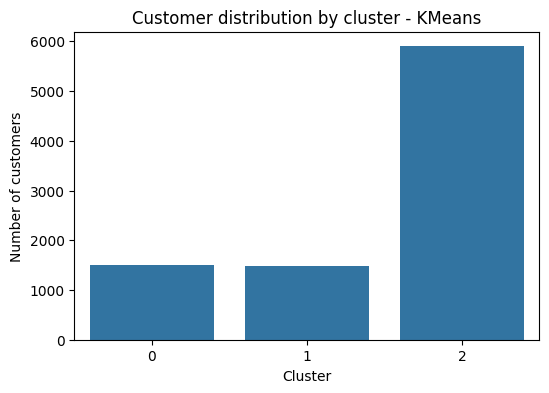

In [37]:
k_kmeans = 3

kmeans = KMeans(n_clusters=k_kmeans, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

df_kmeans = FULL_DF.copy()
df_kmeans["Cluster_KMeans"] = labels_kmeans

print("Customer distribution by cluster:")
display(df_kmeans["Cluster_KMeans"].value_counts().sort_index().to_frame("n_customers"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_kmeans, x="Cluster_KMeans")
plt.title("Customer distribution by cluster - KMeans")
plt.xlabel("Cluster")
plt.ylabel("Number of customers")
plt.show()

In [38]:
df_kmeans.head()

,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure,Cluster_KMeans
Cust_Id,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,95.4,0.000000,0.166667,0.000000,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,2
C10002,3202.467416,0.909091,0.00,0.0,6442.945483,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,0
C10003,2495.148862,1.000000,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,1
C10004,1666.670542,0.636364,1499.00,0.0,205.788017,0.083333,0.083333,0.083333,1.0,1.0,7500.0,0.000000,0.000000,0.000000,12.0,2
C10005,817.714335,1.000000,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,2


<a id="pca"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
9. Principal Component Analysis for Behavioral Visualization
</h1>

PCA is used to summarize the multidimensional structure of customer behavior. In this project, PCA is mainly a tool for visualization and dimensionality reduction, while the segmentation logic is compared across several approaches.

Principal Component Analysis (PCA) is a dimensionality reduction method that transforms a large set of variables into a smaller set that preserves most of the original information.

,Component,Explained_Variance,Cumulative_Variance
0,PC1,0.2543,0.2543
1,PC2,0.2226,0.4769
2,PC3,0.0882,0.5651
3,PC4,0.0751,0.6402
4,PC5,0.0656,0.7057
5,PC6,0.0560,0.7617
6,PC7,0.0534,0.8151
7,PC8,0.0431,0.8582
8,PC9,0.0372,0.8954
9,PC10,0.0304,0.9258


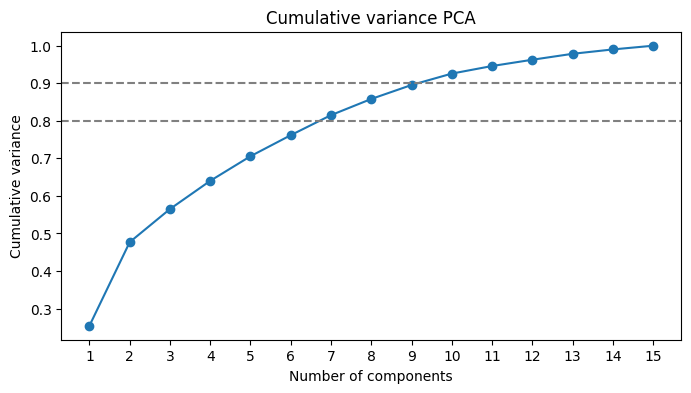

In [39]:
pca = PCA()
pca.fit(X_scaled)

pca_variance = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained_Variance": pca.explained_variance_ratio_,
    "Cumulative_Variance": np.cumsum(pca.explained_variance_ratio_)
})

display(pca_variance.round(4))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.80, linestyle="--", color="gray")
plt.axhline(0.90, linestyle="--", color="gray")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.title("Cumulative variance PCA")
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

<span style="color:#1F4E79;font-weight:700;font-size:22px"> &#10148; PCA with 2 components for visualization </span>

Two components are used for plotting, not because they explain all customer behavior, but because they allow the general structure of the groups to be seen in a plane.


In [41]:
n_pca = 2

pca_2 = PCA(n_components=n_pca)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_loadings = pd.DataFrame(
    pca_2.components_.T,
    index=model_variables,
    columns=[f"PC{i+1}" for i in range(n_pca)]
)

display(pca_loadings.round(3))

for pc in pca_loadings.columns:
    main_loadings = (
        pca_loadings[pc]
        .loc[pca_loadings[pc].abs() >= 0.4]
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\n{pc}: variables with absolute loading greater than or equal to 0.4")
    print(main_loadings.round(3))

,PC1,PC2
Balance,0.196,0.378
Balance_Frequency,0.161,0.109
Purchases,0.434,-0.077
Installments_Purchases,0.373,-0.096
Cash_Advance,0.064,0.449
Purchases_Frequency,0.305,-0.238
One_Off_Purchases_Frequency,0.322,-0.113
Cash_Advance_Frequency,-0.015,0.462
Cash_Advance_Trx,0.026,0.440
Purchases_Trx,0.420,-0.114



PC1: variables with absolute loading greater than or equal to 0.4
Purchases        0.434
Purchases_Trx    0.420
Name: PC1, dtype: float64

PC2: variables with absolute loading greater than or equal to 0.4
Cash_Advance_Frequency    0.462
Cash_Advance              0.449
Cash_Advance_Trx          0.440
Name: PC2, dtype: float64


PC1 mainly summarizes purchase intensity and transactional activity because it has higher loadings on Purchases, Purchases_Trx, Installments_Purchases, Payments and One_Off_Purchases_Frequency. PC1 mainly represents the use of the card for purchases. The variables with the highest weights are Purchases = 0.434 and Purchases_Trx = 0.420; therefore, this component identifies customers who make more purchases and more purchase transactions with their credit card. In simple terms, a customer with a high PC1 value is someone who actively uses the card for consumption: they buy more and make more transactions. This does not necessarily mean the customer is more indebted, but rather that they have higher purchase activity.

PC2 mainly represents the use of the card for cash advances. The variables with the highest weights are Cash_Advance_Frequency = 0.462, Cash_Advance = 0.449 and Cash_Advance_Trx = 0.440. This means that PC2 separates customers who use the card not so much to buy products or services, but to withdraw cash using the credit line. In simple terms, a customer with a high PC2 value usually requests cash through the card more frequently, for higher amounts and in more transactions. This profile may reflect a greater need for immediate liquidity or the use of the card as quick financing.


In [42]:
pca_2_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"], index=df1.index)
pca_2_df["Cluster_KMeans"] = labels_kmeans


print("Explained variance PC1:", round(pca_2.explained_variance_ratio_[0] * 100, 2), "%")
print("Explained variance PC2:", round(pca_2.explained_variance_ratio_[1] * 100, 2), "%")
print("Total explained variance:", round(pca_2.explained_variance_ratio_.sum() * 100, 2), "%")

pca_2_df.head()

Explained variance PC1: 25.43 %
Explained variance PC2: 22.26 %
Total explained variance: 47.69 %


,PC1,PC2,Cluster_KMeans
0,-1.730484,-0.851626,2
1,-0.341286,2.515233,0
2,1.194246,-0.881491,1
3,-0.962680,-0.073074,2
4,-1.497776,-0.541415,2


In [43]:
df_kmeans.head()

,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure,Cluster_KMeans
Cust_Id,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,95.4,0.000000,0.166667,0.000000,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,2
C10002,3202.467416,0.909091,0.00,0.0,6442.945483,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,0
C10003,2495.148862,1.000000,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,1
C10004,1666.670542,0.636364,1499.00,0.0,205.788017,0.083333,0.083333,0.083333,1.0,1.0,7500.0,0.000000,0.000000,0.000000,12.0,2
C10005,817.714335,1.000000,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,2


In [44]:
kmeans_means = pca_2_df.groupby("Cluster_KMeans")[["PC1", "PC2"]].mean().round(2)
kmeans_means.head()

,PC1,PC2
Cluster_KMeans,,
0,0.15,3.15
1,3.00,-1.01
2,-0.79,-0.54


The table shows the average of each cluster in the two principal components. Cluster 0 has a PC1 close to zero and a very high PC2, so it represents customers who stand out not so much for purchases, but for greater use of cash advances; that is, they use the card as a source of quick liquidity. Cluster 1 has a high PC1 and a low PC2, so it groups customers with greater purchase and transaction activity but little use of cash advances. Cluster 2 has low values in PC1 and PC2, indicating customers with lower overall activity: they buy little, make fewer transactions and also do not use cash advances much.


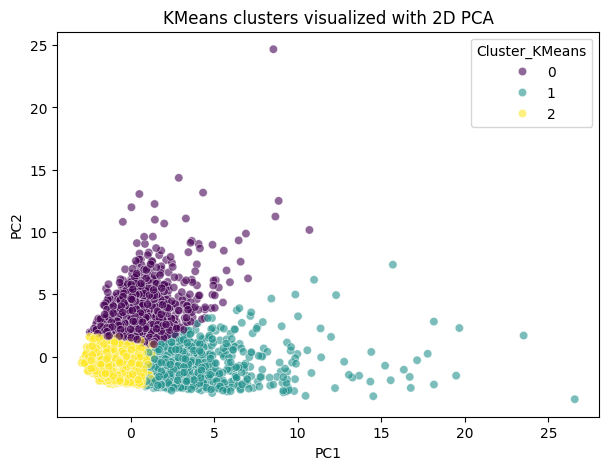

In [45]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_2_df, x="PC1", y="PC2", hue="Cluster_KMeans", palette="viridis", alpha=0.6)
plt.title("KMeans clusters visualized with 2D PCA")
plt.show()

In the graph, the horizontal axis PC1 separates customers according to their purchase intensity: the farther to the right, the greater the use of the card for purchases. The vertical axis PC2 separates customers according to their use of cash advances: the higher the position, the greater the use of cash advance. Therefore, cluster 0 appears mainly in the upper area, associated with customers who withdraw cash with the card; cluster 1 is located farther to the right, associated with frequent buyers; and cluster 2 is concentrated in the lower-left area, representing low-use or low-activity card customers. In summary, KMeans separated three profiles: cash advance users, active buyers and low-activity users.


In [46]:
n_pca = 3

pca_3 = PCA(n_components=n_pca)
X_pca_3 = pca_3.fit_transform(X_scaled)

pca_loadings = pd.DataFrame(
    pca_3.components_.T,
    index=model_variables,
    columns=[f"PC{i+1}" for i in range(n_pca)]
)

display(pca_loadings.round(3))

for pc in pca_loadings.columns:
    main_loadings = (
        pca_loadings[pc]
        .loc[pca_loadings[pc].abs() >= 0.4]
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\n{pc}: variables with absolute loading greater than or equal to 0.4")
    print(main_loadings.round(3))

,PC1,PC2,PC3
Balance,0.196,0.378,0.286
Balance_Frequency,0.161,0.109,0.461
Purchases,0.434,-0.077,-0.113
Installments_Purchases,0.373,-0.096,-0.045
Cash_Advance,0.064,0.449,-0.232
Purchases_Frequency,0.305,-0.238,0.065
One_Off_Purchases_Frequency,0.322,-0.113,0.010
Cash_Advance_Frequency,-0.015,0.462,-0.130
Cash_Advance_Trx,0.026,0.440,-0.193
Purchases_Trx,0.420,-0.114,0.019



PC1: variables with absolute loading greater than or equal to 0.4
Purchases        0.434
Purchases_Trx    0.420
Name: PC1, dtype: float64

PC2: variables with absolute loading greater than or equal to 0.4
Cash_Advance_Frequency    0.462
Cash_Advance              0.449
Cash_Advance_Trx          0.440
Name: PC2, dtype: float64

PC3: variables with absolute loading greater than or equal to 0.4
Balance_Frequency    0.461
Prc_Full_Payment    -0.445
Minimum_Payments     0.413
Name: PC3, dtype: float64


High values in PC3 represent customers whose balance is updated frequently and who usually make minimum payments, but do not necessarily pay the full debt. In contrast, low values in PC3 represent customers who tend to make full credit card payments. In simple terms, PC3 separates customers who pay the minimum and maintain debt from those who pay in full.


In [47]:
pca_3_df = pd.DataFrame(X_pca_3, columns=["PC1", "PC2", "PC3"], index=df1.index)
pca_3_df["Cluster_KMeans"] = labels_kmeans


print("Total explained variance:", round(pca_3.explained_variance_ratio_.sum() * 100, 2), "%")

pca_3_df.head()

Total explained variance: 56.51 %


,PC1,PC2,PC3,Cluster_KMeans
0,-1.730484,-0.851626,0.364348,2
1,-0.341286,2.515233,-0.650079,0
2,1.194246,-0.881491,1.205717,1
3,-0.962680,-0.073074,-0.024397,2
4,-1.497776,-0.541415,0.804862,2


In [48]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans

labels_3d = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
).fit_predict(pca_3_df[["PC1", "PC2"]])

pca_3_df["Cluster_KMeans_PCA"] = labels_3d

fig = px.scatter_3d(
    pca_3_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color=pca_3_df["Cluster_KMeans_PCA"].astype(str),
    title="3D PCA with KMeans colors"
)

fig.show()

In [49]:
DF_3D = pca_3_df.groupby("Cluster_KMeans")[["PC1", "PC2", "PC3"]].mean().round(2)
DF_3D.head()

,PC1,PC2,PC3
Cluster_KMeans,,,
0,0.15,3.15,-0.16
1,3.00,-1.01,0.08
2,-0.79,-0.54,0.02


The clusters differ mainly by PC1 and PC2, while PC3 does not separate the groups very strongly because its averages are close to zero. Cluster 0 has a very high PC2 (3.15) and an almost neutral PC1 (0.15), so it represents customers who stand out for their use of cash advances; that is, people who use the card to withdraw money or finance themselves quickly. Cluster 1 has the highest PC1 (3.00) and a negative PC2 (-1.01), so it groups customers with strong purchase and transaction activity but low use of cash advances. Cluster 2 has low values in PC1 (-0.79) and PC2 (-0.54), so it represents low-activity customers who buy less and also do not use cash advances much. In summary, the profiles are: customers who withdraw cash, active buying customers and customers with low card use.


<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; PCA with 8 components + KMeans
</span>


In [50]:
pca_8 = PCA(n_components=8)
X_pca_8 = pca_8.fit_transform(X_scaled)
print(f"Cumulative explained variance: {pca_8.explained_variance_ratio_.sum()*100:.1f}%")

Cumulative explained variance: 85.8%


In [51]:
pca_loadings = pd.DataFrame(
    pca_8.components_.T,
    index=model_variables,
    columns=[f"PC{i+1}" for i in range(pca_8.n_components)]
)

display(pca_loadings.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Balance,0.196,0.378,0.286,-0.125,-0.036,0.267,0.070,-0.186
Balance_Frequency,0.161,0.109,0.461,0.503,0.079,-0.187,0.098,-0.481
Purchases,0.434,-0.077,-0.113,-0.117,-0.122,-0.034,-0.267,-0.005
Installments_Purchases,0.373,-0.096,-0.045,-0.137,-0.304,-0.321,-0.179,-0.289
Cash_Advance,0.064,0.449,-0.232,0.010,0.066,-0.039,0.103,0.007
Purchases_Frequency,0.305,-0.238,0.065,0.357,-0.032,-0.028,0.234,0.068
One_Off_Purchases_Frequency,0.322,-0.113,0.010,0.332,0.235,0.405,-0.013,0.492
Cash_Advance_Frequency,-0.015,0.462,-0.130,0.275,-0.030,-0.131,-0.057,0.087
Cash_Advance_Trx,0.026,0.440,-0.193,0.252,0.038,-0.255,0.003,0.230
Purchases_Trx,0.420,-0.114,0.019,0.107,-0.110,-0.054,-0.175,0.172


In [52]:
X_pca_model = pd.DataFrame(
    X_pca_8,
    columns=[f"PC{i+1}" for i in range(X_pca_8.shape[1])],
    index=FULL_DF.index
)
X_pca_model.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Cust_Id,,,,,,,,
C10001,-1.730484,-0.851626,0.364348,-0.481806,0.070079,-0.446111,-0.681432,0.029481
C10002,-0.341286,2.515233,-0.650079,-0.954709,0.764119,-0.055291,0.589531,-0.612308
C10003,1.194246,-0.881491,1.205717,1.072057,1.186668,1.860034,0.247978,0.868472
C10004,-0.962680,-0.073074,-0.024397,-1.317292,0.545101,0.849296,-0.568099,-0.068780
C10005,-1.497776,-0.541415,0.804862,-0.161417,0.238122,-0.338966,-0.576964,-0.274893


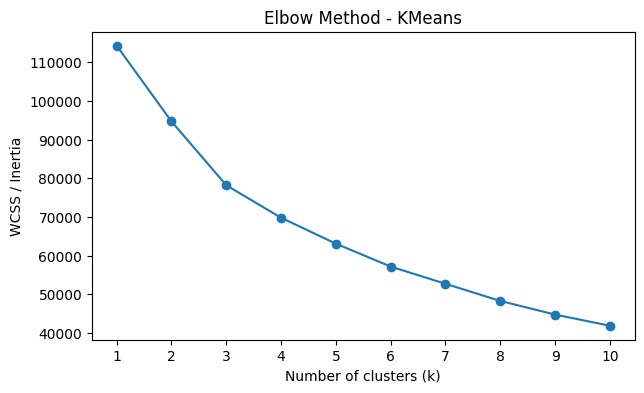

In [47]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_model)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method - KMeans")
plt.xticks(k_range)
plt.show()

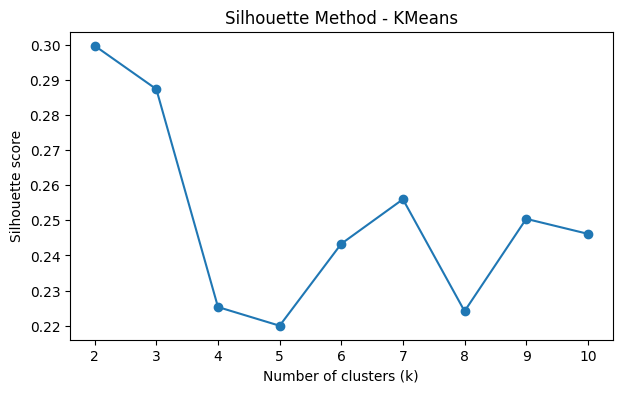

Best k according to silhouette: 2


In [48]:
silhouette = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_model)
    silhouette.append(silhouette_score(X_pca_model, labels))

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), silhouette, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Method - KMeans')
plt.xticks(range(2, 11))
plt.show()

best_k = range(2, 11)[silhouette.index(max(silhouette))]
print('Best k according to silhouette:', best_k)

In [49]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_pca = kmeans_pca.fit_predict(X_pca_model)
X_pca_model["Cluster_KMeans_PCA"] = labels_kmeans_pca
X_pca_model.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Cluster_KMeans_PCA
Cust_Id,,,,,,,,,
C10001,-1.730484,-0.851626,0.364348,-0.481806,0.070079,-0.446111,-0.681432,0.029481,1
C10002,-0.341286,2.515233,-0.650079,-0.954709,0.764119,-0.055291,0.589531,-0.612308,2
C10003,1.194246,-0.881491,1.205717,1.072057,1.186668,1.860034,0.247978,0.868472,0
C10004,-0.962680,-0.073074,-0.024397,-1.317292,0.545101,0.849296,-0.568099,-0.068780,1
C10005,-1.497776,-0.541415,0.804862,-0.161417,0.238122,-0.338966,-0.576964,-0.274893,1


In [50]:
FULL_DF = df1.groupby("Cust_Id").agg({"Balance": "mean", "Balance_Frequency": "mean", "Purchases": "mean", "Installments_Purchases": "mean", "Cash_Advance": "mean", "Purchases_Frequency": "mean", "One_Off_Purchases_Frequency": "mean", "Cash_Advance_Frequency": "mean", "Cash_Advance_Trx": "mean", "Purchases_Trx": "mean", "Credit_Limit": "mean", "Payments": "mean", "Minimum_Payments": "mean", "Prc_Full_Payment": "mean", "Tenure": "mean"})
df_kmeans_pca = FULL_DF.copy()
df_kmeans_pca["Cluster_KMeans_PCA"] = labels_kmeans_pca
df_kmeans_pca.head()

,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure,Cluster_KMeans_PCA
Cust_Id,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,95.4,0.000000,0.166667,0.000000,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,1
C10002,3202.467416,0.909091,0.00,0.0,6442.945483,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,2
C10003,2495.148862,1.000000,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,0
C10004,1666.670542,0.636364,1499.00,0.0,205.788017,0.083333,0.083333,0.083333,1.0,1.0,7500.0,0.000000,0.000000,0.000000,12.0,1
C10005,817.714335,1.000000,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,1


In [51]:
display(df_kmeans_pca["Cluster_KMeans_PCA"].value_counts().sort_index().to_frame("n_customers"))

kmeans_pca_means = df_kmeans_pca.groupby("Cluster_KMeans_PCA")[model_variables].mean().round(2)
display(kmeans_pca_means)

,n_customers
Cluster_KMeans_PCA,
0,1559
1,5861
2,1456


,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure
Cluster_KMeans_PCA,,,,,,,,,,,,,,,
0,1945.69,0.98,3603.50,1323.64,341.72,0.94,0.67,0.05,1.13,49.11,7228.93,3496.68,1067.20,0.29,11.91
1,832.60,0.84,453.41,232.99,378.40,0.43,0.10,0.08,1.39,7.67,3167.57,887.16,518.76,0.15,11.45
2,4181.65,0.96,466.78,162.48,4126.22,0.26,0.12,0.46,13.16,6.67,6977.41,3269.08,1895.55,0.04,11.38


<a id="gmmpca"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
10. Gaussian Mixture Models and Probabilistic Segmentation
</h1>

Gaussian Mixture Models are added to evaluate whether a probabilistic clustering approach provides a useful alternative to K-Means.

**Previous interpretation**

1. KMeans separates customers using centroids and tends to form compact groups. GMM allows elliptical clusters and probabilistic assignment, so it can adapt better when segments overlap or have different dispersion.

2. In PCA, both models are compared in the same reduced space. Thus, the observed difference depends on the clustering algorithm and not on a change in the input variables.

In [53]:
X_scaled.head()

,Balance,Balance_Frequency,Purchases,Installments_Purchases,Cash_Advance,Purchases_Frequency,One_Off_Purchases_Frequency,Cash_Advance_Frequency,Cash_Advance_Trx,Purchases_Trx,Credit_Limit,Payments,Minimum_Payments,Prc_Full_Payment,Tenure
Cust_Id,,,,,,,,,,,,,,,
C10001,-0.736905,-0.287766,-0.426040,-0.349910,-0.468992,-0.806206,-0.681576,-0.678664,-0.478306,-0.512413,-0.961640,-0.531938,-0.299201,-0.528346,0.359995
C10002,0.779306,0.113037,-0.470533,-0.455019,2.593303,-1.221417,-0.681576,0.567547,0.105923,-0.592596,0.684124,0.820499,0.098709,0.229157,0.359995
C10003,0.440093,0.513839,-0.109937,-0.455019,-0.468992,1.269844,2.662996,-0.678664,-0.478306,-0.111498,0.821271,-0.386245,-0.091135,-0.528346,0.359995
C10004,0.042775,-1.089371,0.228579,-0.455019,-0.371182,-1.013812,-0.402863,-0.263262,-0.332249,-0.552505,0.821271,-0.601897,-0.358710,-0.528346,0.359995
C10005,-0.364364,0.513839,-0.463071,-0.455019,-0.468992,-1.013812,-0.402863,-0.678664,-0.478306,-0.552505,-0.906781,-0.366739,-0.254292,-0.528346,0.359995


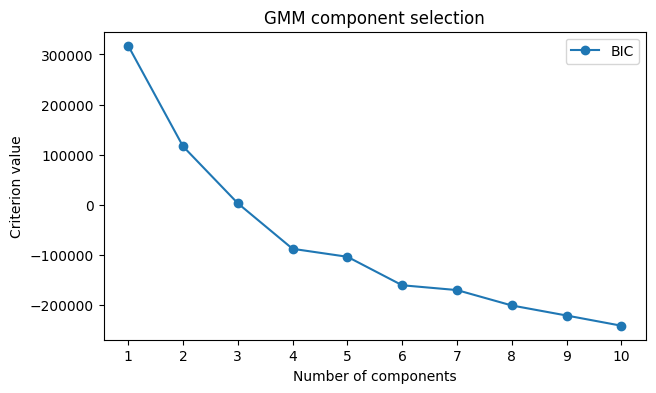

Number of components selected by BIC: 10


In [54]:
from sklearn.mixture import GaussianMixture

bic = []
aic = []
k_range_gmm = range(1, 11)

for k in k_range_gmm:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5)
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))

plt.figure(figsize=(7, 4))
plt.plot(k_range_gmm, bic, marker="o", label="BIC")
plt.xlabel("Number of components")
plt.ylabel("Criterion value")
plt.title("GMM component selection")
plt.legend()
plt.xticks(list(k_range_gmm))
plt.show()

k_gmm = k_range_gmm[bic.index(min(bic))]
print("Number of components selected by BIC:", k_gmm)

In [54]:
gmm = GaussianMixture(n_components=k_gmm, covariance_type="full", random_state=42, n_init=5)
labels_gmm = gmm.fit_predict(X_scaled)
probs_gmm = gmm.predict_proba(X_scaled)

df_gmm = FULL_DF.copy()
df_gmm["Cluster_GMM"] = labels_gmm
df_gmm["Prob_Max_GMM"] = probs_gmm.max(axis=1)

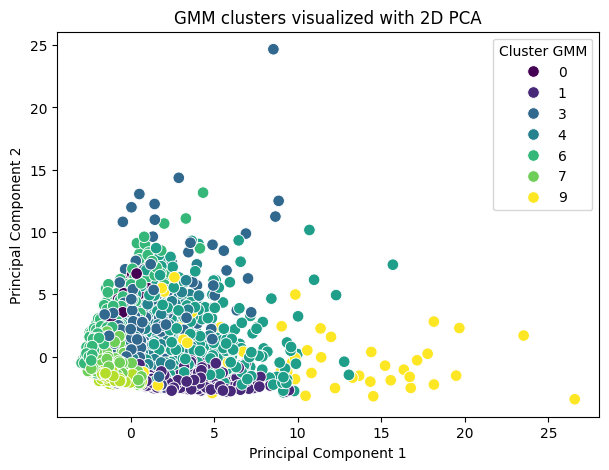

In [55]:
gmm_pca_plot = pd.DataFrame(
    X_pca_8,
    columns=[f"PC{i+1}" for i in range(X_pca_8.shape[1])]
)

gmm_pca_plot["Cluster_GMM"] = labels_gmm
gmm_pca_plot["Prob_Max_GMM"] = probs_gmm.max(axis=1)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=gmm_pca_plot,
    x="PC1",
    y="PC2",
    hue="Cluster_GMM",
    palette="viridis",
    s=70
)
plt.title("GMM clusters visualized with 2D PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster GMM")
plt.show()

Unlike KMeans, GMM does not force compact and circular groups; it allows elliptical and overlapping clusters. Therefore, the graph shows more mixing between colors and more detail in dense areas. This segmentation is useful for distinguishing subprofiles within similar groups, but visually it is less clean than KMeans because several probabilistic components share the same region of the PCA plane.


In [56]:
import plotly.express as px

gmm_pca_3d = gmm_pca_plot.copy()
gmm_pca_3d["Cluster_GMM"] = gmm_pca_3d["Cluster_GMM"].astype(str)

fig = px.scatter_3d(
    gmm_pca_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster_GMM",
    title="GMM clusters with 3D PCA",
    opacity=0.7
)

fig.show()


In both 2 and 3 dimensions, cluster visualization is better with KMeans than with GMM.


<a id="efa"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
11. Exploratory Factor Analysis and Latent Customer Dimensions
</h1>

Exploratory Factor Analysis is included to search for latent dimensions behind the observed customer variables. This complements PCA because it focuses on underlying factors rather than only variance maximization.

<span style="color:#1F4E79;font-weight:700;font-size:20px">
&#10148; Exploratory Factor Analysis (EFA) searches for latent variables (factors) that explain the correlation among observed variables. Unlike PCA, which maximizes variance, EFA models the covariance structure.
</span>

In [57]:
try:
    from factor_analyzer import FactorAnalyzer
    from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "factor_analyzer", "-q"])
    from factor_analyzer import FactorAnalyzer
    from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

<span style="color:#1F4E79;font-weight:700;font-size:25px">
&#10148; KMO Test (Kaiser-Meyer-Olkin)
</span>

Before applying EFA, it is necessary to verify whether the correlation structure of the dataset is suitable for factor analysis.

**Kaiser-Meyer-Olkin (KMO)** measures sampling adequacy by comparing observed correlations vs. partial correlations:

$$\text{KMO}=\frac{\sum\sum_{j\neq k}r^{2}_{jk}}{\sum\sum_{j\neq k}r^{2}_{jk}+\sum\sum_{j\neq k}p^{2}_{jk}}$$

Interpretation criteria:
* **> 0.90** — Excellent
* **0.80 to 0.90** — Very good
* **0.70 to 0.80** — Acceptable
* **0.60 to 0.70** — Fair
* **0.50 to 0.60** — Poor
* **< 0.50** — Unacceptable (EFA is not recommended)


In [58]:
kmo_all,kmo_model=calculate_kmo(FULL_DF)
kmo_model

np.float64(0.7325598140259083)

The data are suitable for Factor Analysis according to the KMO test.


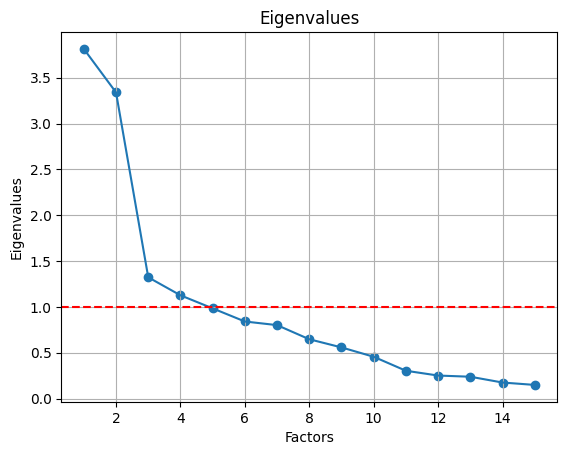

In [59]:
import numpy as np
import matplotlib.pyplot as plt

Sigma = np.cov(X_scaled, rowvar=False)

eigvals, eigvecs = np.linalg.eigh(Sigma)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]

plt.scatter(range(1, len(eigvals)+1), eigvals)
plt.plot(range(1, len(eigvals)+1), eigvals)
plt.title('Eigenvalues')
plt.xlabel('Factors')
plt.ylabel('Eigenvalues')
plt.axhline(y=1, color='r', linestyle='--')
plt.grid()
plt.show()

In [60]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=4)
fa_scores = fa.fit_transform(X_scaled)
loadings = fa.components_.T


In [61]:
uniqueness = fa.noise_variance_ 
ss_loadings = (loadings**2).sum(axis=0)
n_vars = loadings.shape[0]
prop_variance = ss_loadings / n_vars
cum_variance = prop_variance.cumsum()
efa_variance = pd.DataFrame({
    "SS_Loadings": ss_loadings,
    "Proportion": np.round(prop_variance, 4),
    "Cumulative": np.round(cum_variance, 4)
}, index=[f"Factor-{i+1}" for i in range(loadings.shape[1])])
print("Explained variance by each factor (EFA):")
display(efa_variance)

Explained variance by each factor (EFA):


,SS_Loadings,Proportion,Cumulative
Factor-1,2.723383,0.1816,0.1816
Factor-2,2.045411,0.1364,0.3179
Factor-3,2.306490,0.1538,0.4717
Factor-4,0.984851,0.0657,0.5373


The four extracted factors jointly explain 53.73% of the total variance of the original variables. This means that more than half of the information about customer behavior can be summarized in four dimensions: balance/debt, payments and financial movement, cash advances and purchase activity. The remaining variance corresponds to information specific to each variable, noise or patterns that were not captured by the common factors. Although the cumulative percentage is not very high, the factors can be considered useful because they provide a clear interpretation for segmenting customers according to their credit card use.


In [62]:
def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    for _ in range(q):
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
    return Phi @ R

loadings_rotated = varimax(loadings)

In [63]:
loadings = pd.DataFrame(loadings_rotated, index=FULL_DF.columns)
loadings.columns = [f'Factor-{i+1}' for i in range(loadings.shape[1])]
loadings.round(3)

,Factor-1,Factor-2,Factor-3,Factor-4
Balance,0.936,0.134,0.295,-0.075
Balance_Frequency,0.282,-0.085,0.154,-0.253
Purchases,0.102,0.456,-0.105,-0.720
Installments_Purchases,0.076,0.240,-0.094,-0.667
Cash_Advance,0.287,0.371,0.642,0.168
Purchases_Frequency,-0.070,-0.030,-0.198,-0.657
One_Off_Purchases_Frequency,0.034,0.097,-0.063,-0.596
Cash_Advance_Frequency,0.213,0.029,0.856,0.122
Cash_Advance_Trx,0.118,0.092,0.894,0.041
Purchases_Trx,0.092,0.157,-0.061,-0.845


In [ ]:
pip install jinja2

In [64]:
def color_factor_importance(val):
    abs_val = np.abs(val)
    if abs_val > 0.4:
        return 'color: #1F4E79'
    elif abs_val > 0.3:
        return 'color: blue'
    else:
        return 'color: red'

loadings.style.map(color_factor_importance)

,Factor-1,Factor-2,Factor-3,Factor-4
Balance,0.935920,0.133678,0.295464,-0.075034
Balance_Frequency,0.282412,-0.084828,0.154309,-0.252902
Purchases,0.102068,0.456019,-0.104691,-0.720278
Installments_Purchases,0.076028,0.240287,-0.094435,-0.667227
Cash_Advance,0.286687,0.371459,0.642474,0.167967
Purchases_Frequency,-0.069580,-0.029608,-0.198053,-0.657438
One_Off_Purchases_Frequency,0.033553,0.097248,-0.062691,-0.596151
Cash_Advance_Frequency,0.213196,0.029347,0.855723,0.121811
Cash_Advance_Trx,0.117865,0.091815,0.893964,0.040611
Purchases_Trx,0.092176,0.157495,-0.061300,-0.845215


The rotated factors summarize four behavioral profiles: Factor 1 represents the customer's balance or debt level because it loads mainly on Balance, together with minimum payments and credit limit. Factor 2 reflects payment capacity and financial movement because it weighs more on Payments, purchases and transactions. Factor 3 identifies the use of cash advances because it concentrates the Cash_Advance variables, frequency and number of transactions. Finally, Factor 4 is related to purchase activity but with a negative sign; therefore, lower values in this factor indicate customers with greater purchase intensity, installment purchases and frequency of use.


<span style="color:#1F4E79;font-weight:700;font-size:22px"> &#10148; KMeans on factors </span>

KMeans can be applied to the factors to segment customers using summarized dimensions.  
This can be easier to explain than using all the original variables.


In [65]:
factor_scores_df = pd.DataFrame(
    fa_scores,
    columns=[f"Factor_{i+1}" for i in range(4)],
    index=df1.index
)
factor_scores_df.head()


,Factor_1,Factor_2,Factor_3,Factor_4
0,-0.788858,-0.283462,0.038747,0.521461
1,0.862086,0.223903,0.879158,1.160557
2,0.315034,-0.468321,-0.983185,-0.080573
3,-0.059508,-0.599875,-0.233853,0.434814
4,-0.432014,-0.324869,-0.064811,0.711069


In [66]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=20)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


In [67]:
from sklearn.metrics import silhouette_score

silhouette = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette.append(sil)

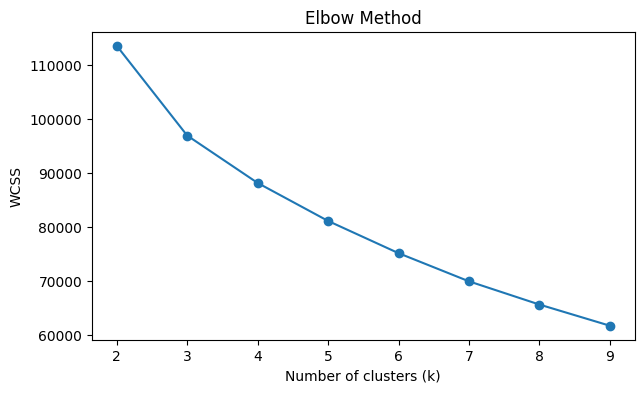

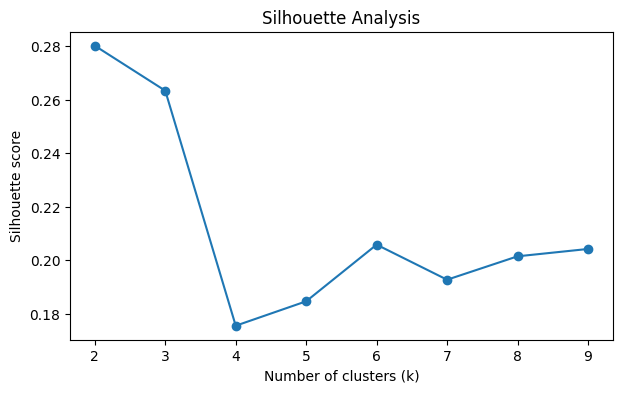

In [68]:
plt.figure(figsize=(7, 4))
plt.plot(range(2,10), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(range(2,10), silhouette, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Analysis")
plt.show()

3 clusters


In [69]:
kmeans_fa = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_fa = kmeans_fa.fit_predict(factor_scores_df)

df_fa = FULL_DF.copy()
df_fa["Cluster_Factors"] = labels_fa



In [70]:

factor_scores_df["Cluster_Factors"] = labels_fa
factor_scores_df.head()


,Factor_1,Factor_2,Factor_3,Factor_4,Cluster_Factors
0,-0.788858,-0.283462,0.038747,0.521461,0
1,0.862086,0.223903,0.879158,1.160557,0
2,0.315034,-0.468321,-0.983185,-0.080573,0
3,-0.059508,-0.599875,-0.233853,0.434814,0
4,-0.432014,-0.324869,-0.064811,0.711069,0


In [71]:
print("Cluster distribution using factors:")
display(df_fa["Cluster_Factors"].value_counts().sort_index().to_frame("n_customers"))


Cluster distribution using factors:


,n_customers
Cluster_Factors,
0,7413
1,1176
2,287


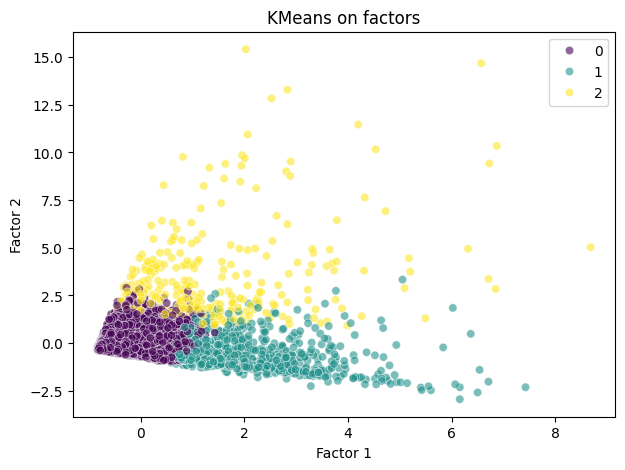

In [72]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=factor_scores_df["Factor_1"], y=factor_scores_df["Factor_2"],
                hue=labels_fa, palette="viridis", alpha=0.6)
plt.title("KMeans on factors")
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.show()

In [73]:
factor_means = factor_scores_df.groupby("Cluster_Factors")[["Factor_1", "Factor_2", "Factor_3", "Factor_4"]].mean().round(2)
display(factor_means)

,Factor_1,Factor_2,Factor_3,Factor_4
Cluster_Factors,,,,
0,-0.35,-0.02,0.01,-0.02
1,1.86,-0.71,-0.29,-0.04
2,1.46,3.51,0.96,0.64


In the factor-based segmentation, cluster 0 groups customers with low financial activity because it has values close to zero or negative in almost all factors; they are users with lower balances, lower movement and no strong purchase or cash advance behavior. Cluster 1 has a high Factor 1 and a negative Factor 2, so it represents customers with higher balance or debt but lower payment and movement levels; this group can be interpreted as customers with greater credit exposure and lower payment dynamism. Cluster 2 is the most active: it has a high Factor 1 and, especially, a very high Factor 2, as well as positive values in Factor 3 and Factor 4. Therefore, it represents customers with greater financial movement, more payments, more card use and also a greater presence of cash advances. In summary, the groups are: low-use customers, customers with higher debt but lower movement, and very active customers with greater payment capacity and intensive card use.


In [74]:
import plotly.express as px

factor_3d_df = factor_scores_df.copy()
factor_3d_df["Cluster_Factors"] = labels_fa

fig = px.scatter_3d(
    factor_3d_df,
    x="Factor_1",
    y="Factor_2",
    z="Factor_3",
    color=factor_3d_df["Cluster_Factors"].astype(str),
    title="Factors 3D con colores KMeans"
)

fig.show()


In [75]:
factor_means

,Factor_1,Factor_2,Factor_3,Factor_4
Cluster_Factors,,,,
0,-0.35,-0.02,0.01,-0.02
1,1.86,-0.71,-0.29,-0.04
2,1.46,3.51,0.96,0.64


Cluster 0 is concentrated near the origin, so it groups low- or moderate-use customers, without much debt or strong movements. Cluster 1 moves more along Factor 1, indicating customers with higher balance or credit exposure but lower payment movement and lower use of cash advances. Cluster 2 separates more toward Factor 2 and Factor 3, so it represents the most active customers: they make more payments, have more financial movement and use more cash advances. In summary, the segmentation distinguishes between low-use customers, customers with higher debt and very active customers with greater financial use of the card.


<span style="color:#1F4E79;font-weight:700;font-size:22px"> &#10148; GMM on factors </span>


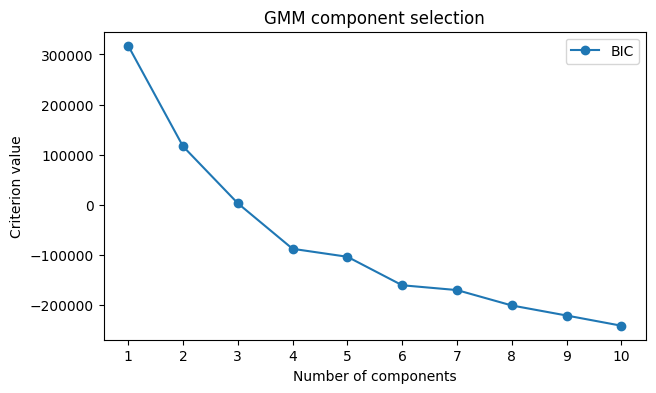

Number of components selected by BIC: 10


In [76]:
from sklearn.mixture import GaussianMixture

bic = []
k_range_gmm = range(1, 11)

for k in k_range_gmm:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5)
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))

plt.figure(figsize=(7, 4))
plt.plot(k_range_gmm, bic, marker="o", label="BIC")
plt.xlabel("Number of components")
plt.ylabel("Criterion value")
plt.title("GMM component selection")
plt.legend()
plt.xticks(list(k_range_gmm))
plt.show()

k_gmm = k_range_gmm[bic.index(min(bic))]
print("Number of components selected by BIC:", k_gmm)

In [77]:
gmm = GaussianMixture(n_components=k_gmm, covariance_type="full", random_state=42, n_init=5)
labels_gmm = gmm.fit_predict(X_scaled)
probs_gmm = gmm.predict_proba(X_scaled)

df_gmm = FULL_DF.copy()
df_gmm["Cluster_GMM"] = labels_gmm
df_gmm["Prob_Max_GMM"] = probs_gmm.max(axis=1)

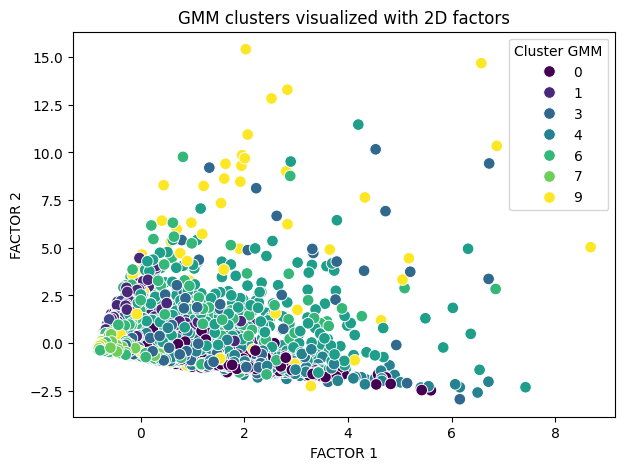

In [78]:
gmm_pca_plot = pd.DataFrame(
    factor_scores_df,
    columns=[f"Factor_{i+1}" for i in range(factor_scores_df.shape[1])]
)

gmm_pca_plot["Cluster_GMM"] = labels_gmm
gmm_pca_plot["Prob_Max_GMM"] = probs_gmm.max(axis=1)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=gmm_pca_plot,
    x="Factor_1",
    y="Factor_2",
    hue="Cluster_GMM",
    palette="viridis",
    s=70
)
plt.title("GMM clusters visualized with 2D factors")
plt.xlabel("FACTOR 1")
plt.ylabel("FACTOR 2")
plt.legend(title="Cluster GMM")
plt.show()

In [79]:
import plotly.express as px

gmm_pca_plot["Cluster_GMM"] = gmm_pca_plot["Cluster_GMM"].astype(str)

fig = px.scatter_3d(
    gmm_pca_plot,
    x="Factor_1",
    y="Factor_2",
    z="Factor_3",
    color="Cluster_GMM",
    title="GMM clusters visualized with 3D factors",
    opacity=0.7
)

fig.show()

Segmentation through finite mixtures is not as interpretable as KMeans because the BIC criterion selects 10 clusters as the optimal solution. In both 2D and 3D factor plots, the clusters cannot be interpreted correctly. Therefore, for the customer credit card usage dataset, it is better to perform segmentation with KMeans.


A limitation of the study is that it focused only on two clustering methods: KMeans and GMM. Although both methods allow behavior patterns to be identified among credit card customers, other approaches such as hierarchical clustering or density-based methods were not included, and these could complement the evaluation of the segments found. Likewise, cluster visualization has a natural limitation because it is not possible to fully represent spaces with more than three dimensions. In the case of PCA, the three-dimensional graph uses three principal components that explain approximately 55% of the total variance, so part of the original information is not reflected in the visualization. In the case of Exploratory Factor Analysis, the four factors explain around 53.73% of the total variance; however, when only three factors are plotted, one relevant dimension is also left out. Therefore, the graphs should be interpreted as a visual approximation of the segmentation patterns, not as a complete representation of the information contained in the original variables.


Based on the results obtained, KMeans is more suitable than GMM for this dataset because it generates simpler, more defined and more commercially interpretable groups. Although GMM selects ten clusters according to the BIC criterion, this solution fragments the sample too much and makes it difficult to read clear customer profiles. In contrast, KMeans makes it possible to identify more understandable segments, such as low-use customers, customers with high purchase activity and customers with greater use of cash advances. Regarding dimensionality reduction, PCA is more convenient for visualizing clusters because it summarizes the greatest possible variability in a few components. However, Exploratory Factor Analysis provides a clearer interpretation of financial behavior by organizing the variables into latent dimensions such as balance or debt, payments, cash advances and purchase activity. Consequently, PCA is considered more useful for graphically representing the groups, while Factor Analysis provides a better explanation of each segment profile.


<a id="references"></a>
<h1 style="
background:#1F4E79;
color:white;
padding:12px 16px;
border-radius:8px;
font-family:Arial, Helvetica, sans-serif;
text-align:center;">
12. References and Originality Statement
</h1>

This project uses a public credit-card customer dataset for educational and portfolio purposes. The modeling, explanations, interpretation tables and final business discussion were reorganized and extended to build an independent analysis.

When publishing this repository, the dataset source should be credited in the `README.md`. If any external notebook, article or tutorial influenced the structure or code, it should also be mentioned in the references. Proper attribution protects the project from plagiarism concerns and makes the work more transparent.

### Suggested citation note for GitHub

> Data source: Public credit card customer segmentation dataset.  
> Project contribution: independent preprocessing, exploratory analysis, K-Means segmentation, PCA visualization, GMM comparison, exploratory factor analysis and business interpretation.
